# Determining Drag Area Coefficient from Cruising Tests

**Author:** Ryan Huang

**Date:** 2026-05-16

**Relevant Links:**
- This analysis reuses some code from the [2025 Brightside Cruise Test](https://github.com/UBC-Solar/data_analysis/blob/main/v3/motor_analysis/motor_testing_april_6.ipynb)

## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os
import dill
from data_tools.collections import TimeSeries
from data_tools.query import DBClient
from datetime import datetime
from pathlib import Path


## Data Acquisition

Obtain the data relevant to this analysis. Load data from saved files, or query it directly.

In [30]:
LOAD_FROM_FILE = False 
DATA_DIR = Path("data")

if LOAD_FROM_FILE:
    
    speed_file = DATA_DIR / "cruise_motor_speeds.bin"
    current_file = DATA_DIR / "cruise_pack_currents.bin"
    brake_file = DATA_DIR / "cruise_brake_presseds.bin"
    with open(speed_file, "rb") as f:
        cruise_speeds: list[TimeSeries] = dill.load(f)
    with open(current_file, "rb") as f:
        cruise_pack_currents: list[TimeSeries] = dill.load(f)
    with open(brake_file, "rb") as f:
        cruise_brake_presseds: list[TimeSeries] = dill.load(f)

else:
    client = DBClient()
    PACK_CURRENT_THRESHOLD = 0.10682  # pack current never reads 0; its lowest value is this constant (constant is rounded up here)
    start_times = [datetime.fromisoformat("2026-04-02T20:02:25Z"),
                   datetime.fromisoformat("2026-04-02T20:07:05Z"),
                   datetime.fromisoformat("2026-04-02T20:25:57Z"),
                   datetime.fromisoformat("2026-04-02T20:35:34Z"),
                   datetime.fromisoformat("2026-04-02T21:05:20Z"),
                   datetime.fromisoformat("2026-04-02T21:10:19Z"),]
    
    stop_times = [datetime.fromisoformat("2026-04-02T20:03:02Z"),
                  datetime.fromisoformat("2026-04-02T20:07:31Z"),
                  datetime.fromisoformat("2026-04-02T20:26:38Z"),
                  datetime.fromisoformat("2026-04-02T20:36:12Z"),
                  datetime.fromisoformat("2026-04-02T21:05:46Z"),
                  datetime.fromisoformat("2026-04-02T21:10:46Z"),]
    
    cruise_speeds: list[TimeSeries] = []
    cruise_pack_currents: list[TimeSeries] = []
    cruise_brake_presseds: list[TimeSeries] = []

    for start, stop in zip(start_times, stop_times):
        motor_rotating_speed: TimeSeries = client.query_time_series(start=start, stop=stop, field="MotorRotatingSpeed", units="km/h")
        pack_current: TimeSeries = client.query_time_series(start=start, stop=stop, field="PackCurrent", units="A")
        brake_pressed: TimeSeries = client.query_time_series(start=start, stop=stop, field="BrakePressed")

        motor_rotating_speed, pack_current, brake_pressed = TimeSeries.align( # different sampling rates for each data
            motor_rotating_speed, pack_current, brake_pressed
        ) 

        cruise_speeds.append(motor_rotating_speed)
        cruise_pack_currents.append(pack_current)
        cruise_brake_presseds.append(brake_pressed)

    # with open(DATA_DIR / "cruise_motor_speeds.bin", 'wb') as f:
    #     dill.dump(cruise_motor_speeds, f)
    # with open(DATA_DIR / "cruise_pack_currents.bin", 'wb') as f:
    #     dill.dump(cruise_pack_currents, f)
    # with open(DATA_DIR / "cruise_brake_presseds.bin", 'wb') as f:
    #     dill.dump(cruise_brake_presseds, f)

## Analysis

Compute the desired results and present them. Take advantage of Markdown cells to guide the reader through your derivation process.

### Plotting the Data

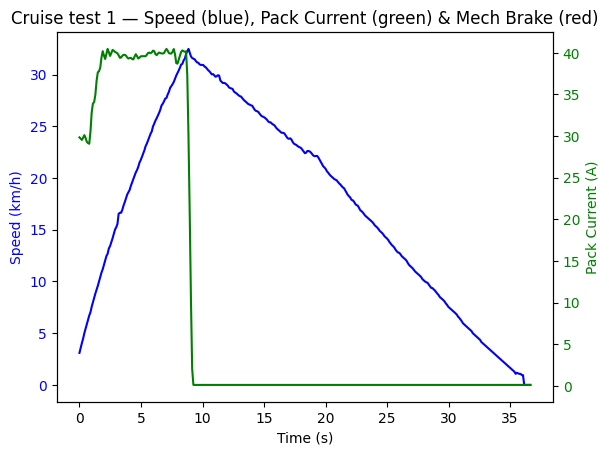

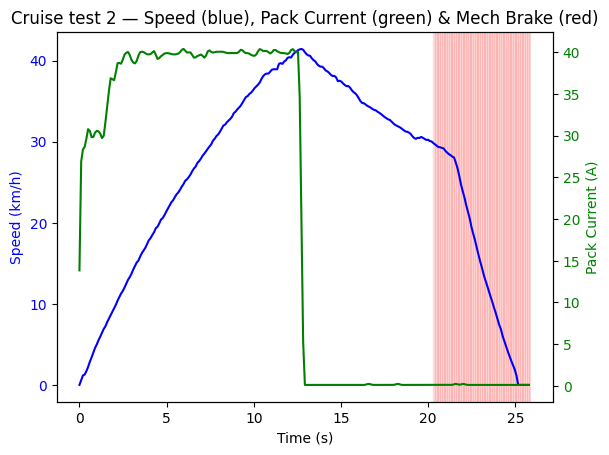

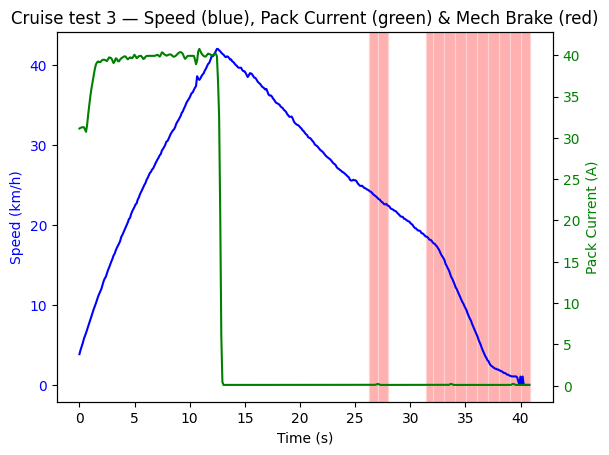

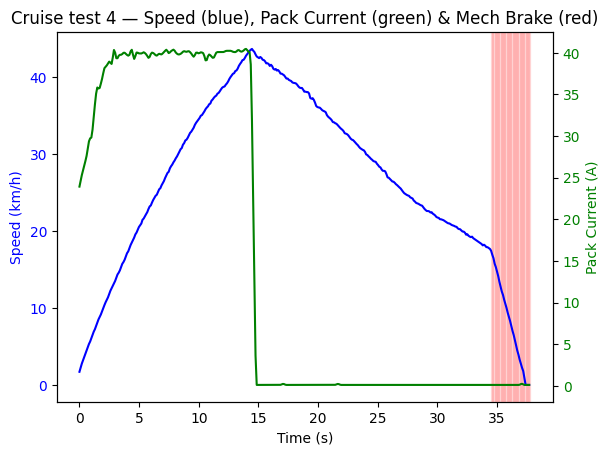

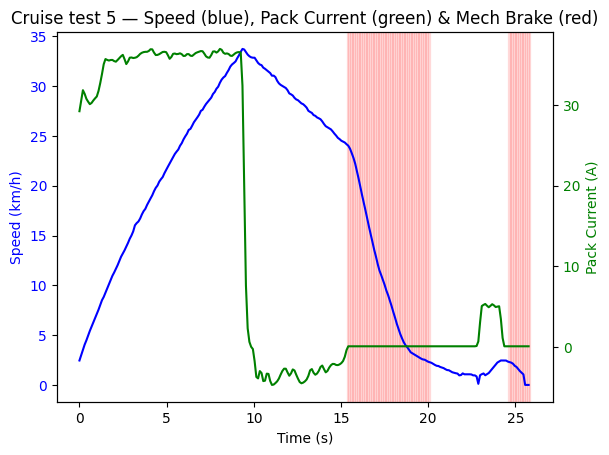

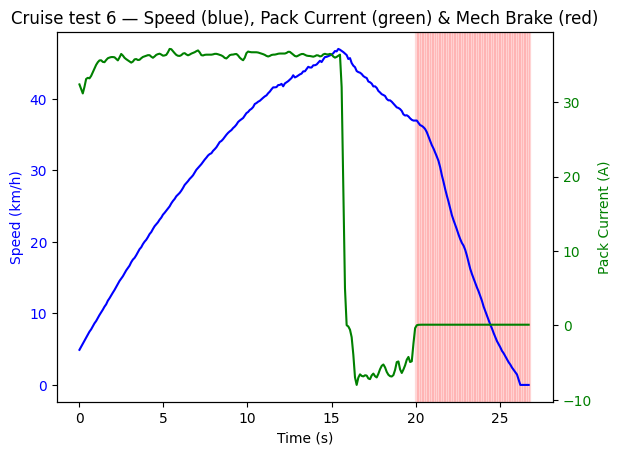

In [37]:
for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    fig, ax1 = plt.subplots()
    t_axis = speed.x_axis
    period = speed.period

    # Plot Speed (km/h) on the left y-axis
    ax1.plot(t_axis, speed, color='blue')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Speed (km/h)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create a secondary y-axis for pack current (A)
    ax2 = ax1.twinx()
    ax2.plot(t_axis, current, color='green')
    ax2.set_ylabel('Pack Current (A)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Change background color based on brake (1 or 0)
    for j, value in enumerate(brake):
        if value == 1:
            ax1.axvspan(t_axis[j], t_axis[j]+period, color='red', alpha=0.1)  # Highlight background when brake is pressed
    
    plt.title(f"Cruise test {i+1} — Speed (blue), Pack Current (green) & Mech Brake (red)")
    plt.show()


### Analysis

In [ ]:
for i, speed in enumerate(cruise_speeds):
    KMH_PER_MPS = 3.6
    acceleration = (np.diff(speed) / speed.period) / KMH_PER_MPS

#### Extracting cruise test windows

In [ ]:
cruise_start_index = np.where(pack_current <= PACK_CURRENT_THRESHOLD)[0][0]
cruise_end_index = np.where(brake_pressed > 0)[0][0]

cruise_start_time = pack_current.datetime_x_axis[cruise_start_index]
cruise_end_time = brake_pressed.datetime_x_axis[cruise_end_index]

cruise_speeds.append(motor_rotating_speed.slice(cruise_start_time, cruise_end_time))
cruise_pack_currents.append(pack_current.slice(cruise_start_time, cruise_end_time))
cruise_brake_presseds.append(brake_pressed.slice(cruise_start_time, cruise_end_time))